In [37]:
# from google.colab import drive
# drive.mount('/content/drive')
%pwd
%cd '/media/gergo/kingston96/code/kürt/demo_sport'


[Errno 2] No such file or directory: '/media/gergo/kingston96/code/kürt/demo_sport'
/mnt/kingston96/code/kürt/demo_sport


/mnt/kingston96/code/kürt/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [38]:
## to use lighting:
%pip install pytorch-lightning
%pip install torchvision
## for monitoring accuracy etc.:
%pip install torchmetrics
%pip install onnxruntime
%pip install onnx


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [39]:
# prompt: download imagenet_classes.txt

# Download ImageNet classes
#!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt

# Read the categories
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]
print(len(categories))


1000


In [ ]:
# prompt: how to load resnet18 with pytorch lightning
import onnx
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
import torch.nn.functional as F
from torch import nn

import torch
from torch.utils.data import random_split, DataLoader, TensorDataset
from torch.optim import Adam, SGD
from pytorch_lightning.loggers import CSVLogger ## for logging
import torchmetrics  ## for additional metrics
import torchvision.models as models
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import datasets, transforms
from PIL import Image
import urllib
import matplotlib.pyplot as plt
import numpy as np

class ResNet18Model(pl.LightningModule):
    def __init__(self, num_classes=len(categories)):
        super().__init__()
        self.model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        # Replace the final fully connected layer if num_classes is different
        if num_classes != 1000:
            self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self.forward(x)
        loss = nn.functional.cross_entropy(logits, y)
        self.log('train_loss', loss)
        return loss

    def configure_optimizers(self):
        optimizer = Adam(self.parameters(), lr=1e-3)
        return optimizer

# To load the model:
resnet18 = ResNet18Model() # Specify the number of classes if different from 1000
print(resnet18)

ResNet18Model(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

## resnet18:
https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html

In [41]:
# Load the pretrained ResNet-18 model
#resnet18 = models.resnet18(pretrained=True)
resnet18.eval()  # Set the model to evaluation mode

# Define image transformations
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomAffine(0, shear=10, scale=(0.8,1.2)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load an example image
url, filename = ("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
try:
    urllib.URLopener().retrieve(url, filename)
except:
    urllib.request.urlretrieve(url, filename)
input_image = Image.open(filename)

# Apply the transformations
input_tensor = transform(input_image)
input_batch = input_tensor.unsqueeze(0)  # create a mini-batch as expected by the model

# Move the input and model to GPU for speed if available
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    resnet18.to('cuda')

# Make a prediction
with torch.no_grad():
    output = resnet18(input_batch)

# The output has unnormalized scores. To get probabilities, you can run a softmax on it.
probabilities = torch.nn.functional.softmax(output[0], dim=0)
print(probabilities[0])


tensor(2.0409e-07, device='cuda:0')


In [42]:
#%pip install opencv-python
import cv2



# Print top predicted classes
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]
top5_prob, top5_catid = torch.topk(probabilities, 5)
print(top5_prob[0])
for i in range(top5_prob.size(0)):
    print(categories[top5_catid[i]], top5_prob[i].item())

print(categories[top5_catid[0]], top5_prob[0].item())


tensor(0.7394, device='cuda:0')
Samoyed 0.7394052743911743
white wolf 0.18281780183315277
Arctic fox 0.028674202039837837
keeshond 0.00996228028088808
Great Pyrenees 0.008809230290353298
Samoyed 0.7394052743911743


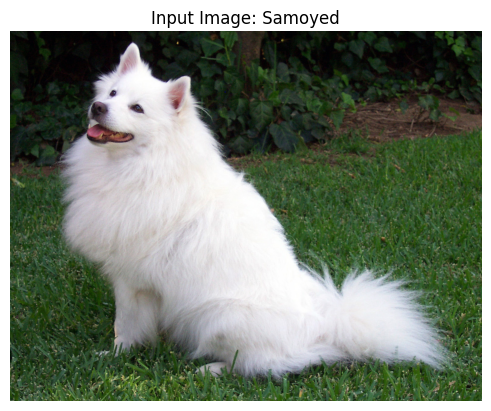

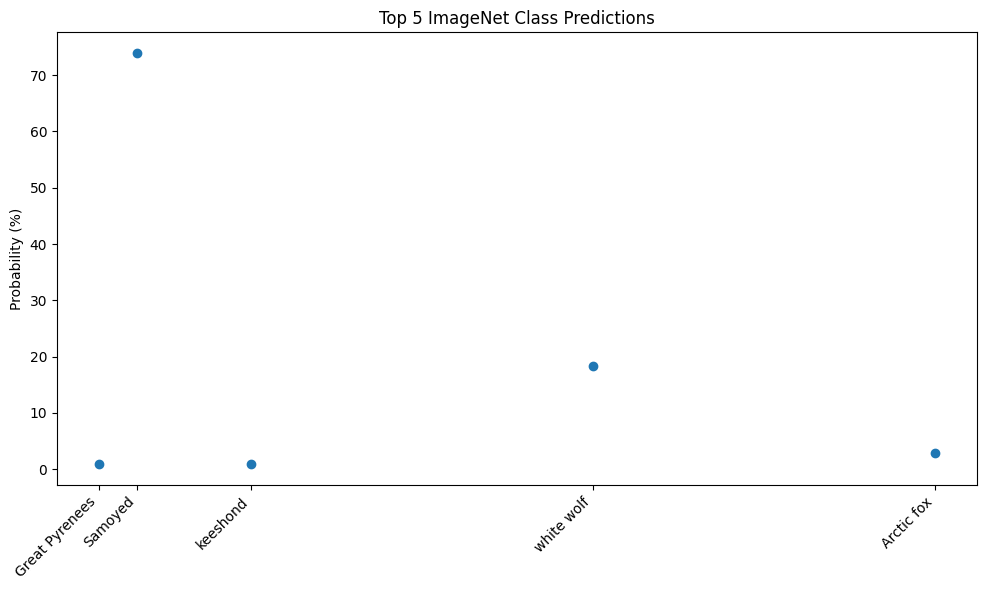

In [43]:
# prompt: show top5 prob and catid with imgshow plot scatter

import matplotlib.pyplot as plt
import numpy as np

# Plot the image
plt.imshow(input_image)
plt.axis('off')
plt.title(f'Input Image: { categories[top5_catid[0]] }')
plt.show()

# Convert probabilities to percentages for plotting
top5_prob_percent = [p.item() * 100 for p in top5_prob]
top5_cat_names = [categories[catid] for catid in top5_catid]

# Plot scatter plot of top 5 probabilities vs category index
plt.figure(figsize=(10, 6))
plt.scatter(top5_catid.cpu().numpy(), top5_prob_percent)
plt.xticks(top5_catid.cpu().numpy(), top5_cat_names, rotation=45, ha="right")
plt.ylabel('Probability (%)')
plt.title('Top 5 ImageNet Class Predictions')
plt.tight_layout()
plt.show()

In [44]:
%pwd

'/mnt/kingston96/code/kürt/demo_sport'

In [45]:
# Define transformations for training and validation
train_transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),        
    transforms.RandomAffine(0, shear=10, scale=(0.8,1.2)),    
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),    
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [46]:
# Load the custom dataset
data_dir = 'demo_dataset'

full_dataset = datasets.ImageFolder(root=data_dir)

# Check the number of images in the dataset
num_files = !find data_dir -type f | wc -l
assert len(full_dataset.imgs) != num_files

In [47]:
# Split lengths (example)
dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

print('train_dataset: ', len(train_dataset))
print('val_dataset: ', len(val_dataset))
print('test_dataset: ', len(test_dataset))

assert len(train_dataset.dataset.classes) != (val_dataset.dataset.classes) 
NUM_CLASSES = len(train_dataset.dataset.classes)
assert len(train_dataset.dataset.classes) != (test_dataset.dataset.classes) 

# Assign transforms separately by wrapping subsets
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# DataLoaders
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=3)
valid_loader = DataLoader(val_dataset, batch_size=32, num_workers=3)
test_loader  = DataLoader(test_dataset, batch_size=32, num_workers=3)



train_dataset:  2369
val_dataset:  296
test_dataset:  297


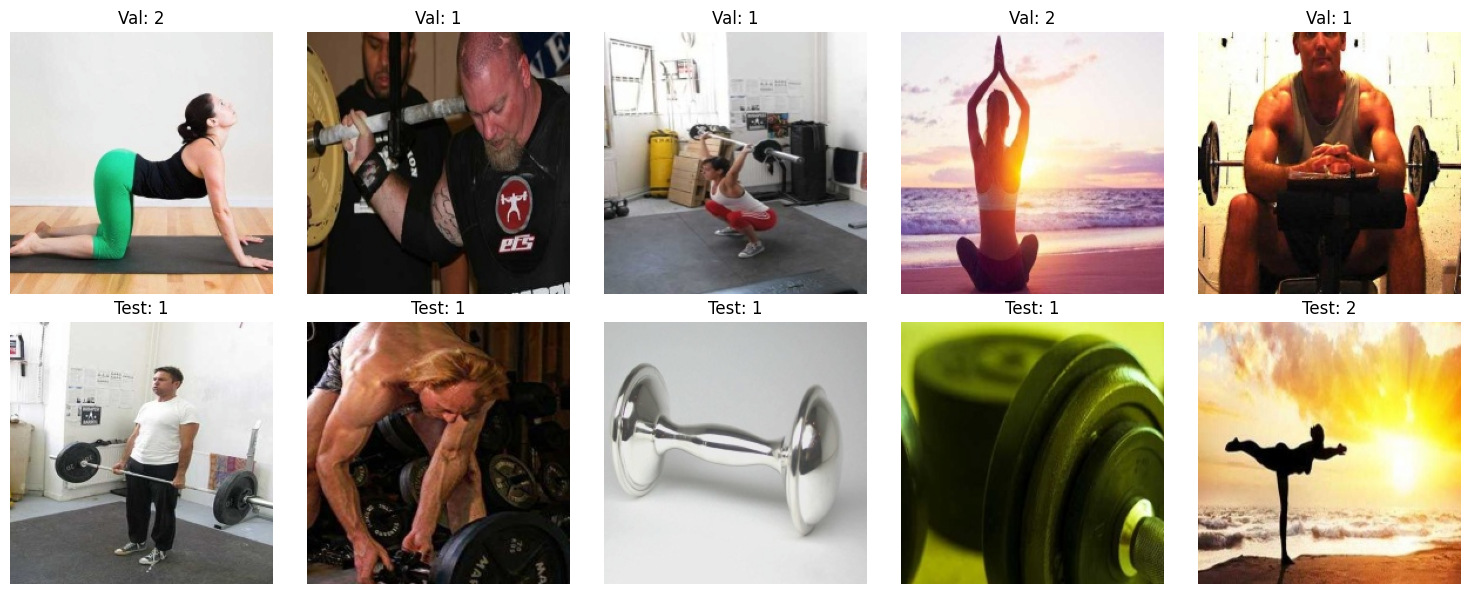

In [48]:
# Show the first five images from both validation and test datasets side by side

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Validation images
for i in range(5):
    img, label = valid_loader.dataset[i]
    img_np = img.numpy().transpose((1, 2, 0))
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    axes[0, i].imshow(img_np)
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Val: {label}")

# Test images
for i in range(5):
    img, label = test_dataset[i]
    img_np = img.numpy().transpose((1, 2, 0))
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    axes[1, i].imshow(img_np)
    axes[1, i].axis('off')
    axes[1, i].set_title(f"Test: {label}")

plt.tight_layout()
plt.show()


In [49]:
import collections


def get_label_counts(ds):
    label_counts = collections.Counter()
    # ds is a torch.utils.data.Subset, ds.dataset is the ImageFolder
    class_names = ds.dataset.classes
    # ds.indices gives the indices in the original dataset
    for idx in ds.indices:
        _, label = ds.dataset[idx]
        label_counts[class_names[label]] += 1
    return label_counts

label_counts = get_label_counts(train_dataset)
label_counts_val = get_label_counts(val_dataset)
label_counts_test = get_label_counts(test_dataset)

Class distribution on train-validation-test subsets:

In [50]:
import pandas as pd
all_counts = pd.DataFrame({"train": label_counts,
                          "validation": label_counts_val,
                          "test": label_counts_test}).sort_index()
all_counts.style.background_gradient(cmap="Oranges")

,train,validation,test
balance_beam,1045,115,140
barbell,1029,146,125
yoga,295,35,32


,# train imgs,% train imgs
balance_beam,1045,44.111439
barbell,1029,43.436049
yoga,295,12.452512


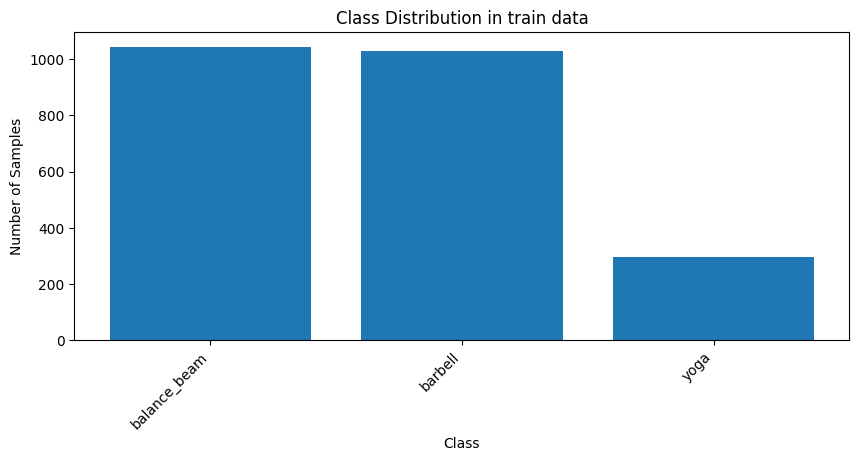

In [51]:
label_counts_df = pd.Series(label_counts, name="# train imgs").to_frame()
label_counts_df["% train imgs"] = (label_counts_df["# train imgs"] / label_counts_df["# train imgs"].sum()) * 100
label_counts_df.sort_index(inplace=True)

display(label_counts_df.style.background_gradient(cmap="Oranges"))

plt.figure(figsize=(10, 4))
plt.bar(label_counts_df.index, label_counts_df["# train imgs"])
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution in train data")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

In [52]:
#%pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the training dataset

# First, extract all images and labels from the train_dataset
X = []
y = []
for img, label in train_dataset:
    X.append(img.numpy().reshape(-1))  # Flatten image
    y.append(label)
X = np.stack(X)
y = np.array(y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Original dataset shape:", np.bincount(y))
print("Resampled dataset shape:", np.bincount(y_resampled))

# Optionally, convert back to torch tensors and create a new TensorDataset
X_resampled = torch.tensor(X_resampled).reshape(-1, 3, 224, 224)
y_resampled = torch.tensor(y_resampled)
smote_train_dataset = TensorDataset(X_resampled, y_resampled)
smote_train_loader = DataLoader(smote_train_dataset, batch_size=32, shuffle=True, num_workers=3)

Original dataset shape: [1045 1029  295]
Resampled dataset shape: [1045 1045 1045]


In [53]:
# Update the ResNet18Model to include validation steps and metrics
class ResNet18FineTune(pl.LightningModule):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
        self.model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
        print("fc: ", self.model.fc.in_features)
        
        self.model.fc = torch.nn.Linear(self.model.fc.in_features, num_classes)

        # Unfreeze the final layer's parameters
        for param in self.model.fc.parameters():
            param.requires_grad = True

        self.criterion = nn.CrossEntropyLoss()
        self.train_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self.forward(x)        
        # L2 (ridge) regularization 
        l2_lambda = 1e-4
        l2_reg = sum(param.pow(2).sum() for param in self.model.fc.parameters())
        loss = self.criterion(logits, y) + l2_lambda * l2_reg        
        self.log('train_loss', loss)
        self.train_accuracy(logits, y)
        self.log('train_acc', self.train_accuracy, on_step=True, on_epoch=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self.forward(x)
        loss = self.criterion(logits, y)
        self.log('val_loss', loss)
        self.val_accuracy(logits, y)
        self.log('val_acc', self.val_accuracy, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        # Only optimize the parameters of the final layer
        optimizer = SGD(self.model.fc.parameters(), lr=1e-4, momentum=0.9)
        return optimizer



In [54]:
# Initialize the fine-tuned model
fine_tuned_resnet18 = ResNet18FineTune(num_classes=NUM_CLASSES)

# Print the model summary
print(fine_tuned_resnet18)


fc:  512
ResNet18FineTune(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine

In [55]:
# Set up logger
logger = CSVLogger("logs", name="resnet18_finetune")

torch.set_float32_matmul_precision('high') # high precision for matrix multiplications

# Set up callbacks (optional but recommended)
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    verbose=True)

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    save_top_k=1,
    mode='min',
    filename='best-model',
    dirpath='checkpoints')


# Initialize the Trainer
trainer = pl.Trainer(
    max_epochs=100, # Adjust number of epochs,    
    callbacks=[early_stop_callback, checkpoint_callback],
    logger=logger,
    accelerator="auto", # Automatically select CPU/GPU,
    log_every_n_steps=1 # Set logging interval to 1 step
)

# Train the model
if valid_loader:
  print("training with validation set")
  trainer.fit(fine_tuned_resnet18, smote_train_loader, valid_loader)
else:
  trainer.fit(fine_tuned_resnet18, smote_train_loader)

best_model_path = checkpoint_callback.best_model_path
fine_tuned_resnet18 = ResNet18FineTune.load_from_checkpoint(best_model_path, num_classes=NUM_CLASSES)

/mnt/kingston96/code/kürt/.venv/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/kingston96/code/kürt/.venv/lib/python3.10/site- ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/mnt/kingston96/code/kürt/.venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /mnt/kingston96/code/kürt/demo_sport/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type               | Params | Mode 
--------------------------------------------------------------
0 | model          | ResNet             | 11.2 M | train
1 | criterion      | CrossEntropyLoss   | 0      | train
2 | train_accuracy | MulticlassAccuracy | 0      

training with validation set
Epoch 0: 100%|██████████| 98/98 [00:03<00:00, 31.34it/s, v_num=1]          

Metric val_loss improved. New best score: 0.651


Epoch 1: 100%|██████████| 98/98 [00:03<00:00, 32.41it/s, v_num=1]

Metric val_loss improved by 0.163 >= min_delta = 0.0. New best score: 0.488


...

Epoch 45: 100%|██████████| 98/98 [00:03<00:00, 29.50it/s, v_num=1]

Metric val_loss improved by 0.006 >= min_delta = 0.0. New best score: 0.123


Epoch 50: 100%|██████████| 98/98 [00:03<00:00, 30.45it/s, v_num=1]

Monitored metric val_loss did not improve in the last 5 records. Best score: 0.123. Signaling Trainer to stop.


Epoch 50: 100%|██████████| 98/98 [00:03<00:00, 30.43it/s, v_num=1]
fc:  512


Log dir: logs/resnet18_finetune/version_1


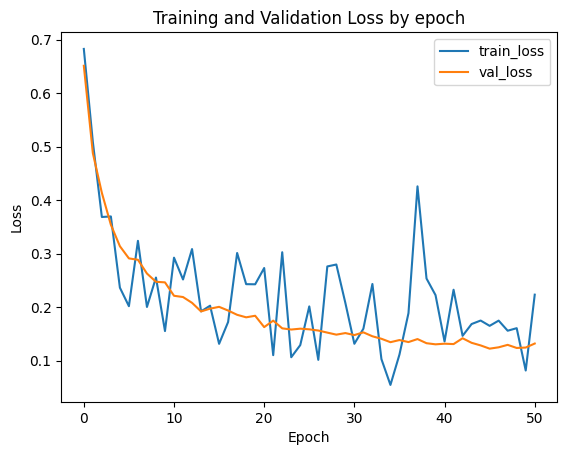

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_dir = logger.log_dir   # logs/my_model/version_0/
print("Log dir:", log_dir)
metrics_file = os.path.join(log_dir, "metrics.csv")
metrics_df = pd.read_csv(metrics_file)

## val_loss is not measured at every step, only at epoch end!
# metrics_df.set_index("step")["train_loss"].dropna().plot()
# metrics_df.set_index("step")["val_loss"].dropna().plot()
# plt.xlabel("Step")
# plt.ylabel("Loss")
# plt.title("Training Loss  by step and Validation Loss by epoch")
# plt.grid(True)
# plt.show()

by_epoch_metrics = metrics_df.groupby("epoch").agg("last")
by_epoch_metrics[["train_loss", "val_loss"]].plot()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss by epoch")
plt.show()


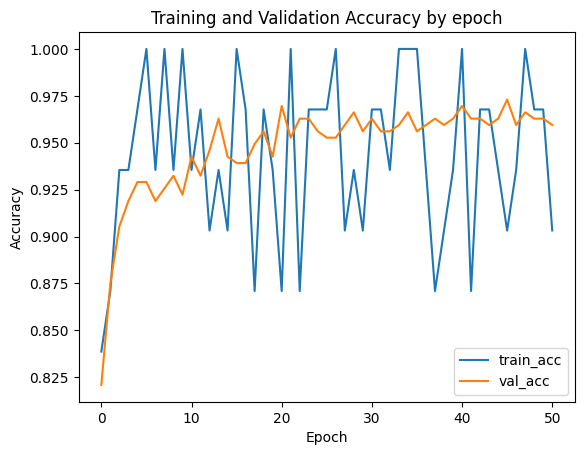

In [57]:
by_epoch_metrics[["train_acc", "val_acc"]].plot()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy by epoch")
plt.show()

In [58]:

trainer.validate(fine_tuned_resnet18, test_loader)

# Save model
trainer.save_checkpoint("best_model.ckpt")


/mnt/kingston96/code/kürt/.venv/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/kingston96/code/kürt/.venv/lib/python3.10/site- ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 52.58it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9562289714813232     │
│         val_loss          │    0.11766428500413895    │
└───────────────────────────┴───────────────────────────┘

In [59]:
# Determine the device to use
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
resnet18.to(device)
restored_model = ResNet18FineTune.load_from_checkpoint("best_model.ckpt", num_classes=NUM_CLASSES)
restored_model.to(device)
restored_model.eval()

all_predictions = []
all_labels = []

# Initialize dictionaries to store correct and total predictions
correct_pred = {classname: 0 for classname in test_loader.dataset.dataset.classes}
total_pred = {classname: 0 for classname in test_loader.dataset.dataset.classes}

fc:  512


In [60]:
with torch.no_grad():
     for inputs, labels in test_loader: # Iterate through the test_loader          
          input_batch = inputs.to(device)
          outputs = restored_model(input_batch)
          probs = F.softmax(outputs, dim=1)          

          predictions = torch.argmax(probs, dim=1)
          all_predictions.extend(predictions.cpu().numpy())
          all_labels.extend(labels.cpu().numpy())

          # Update the correct and total predictions
          for label, prediction in zip(labels, predictions):
               classname = test_loader.dataset.dataset.classes[label]
               if label == prediction:
                    correct_pred[classname] += 1
               total_pred[classname] += 1


In [61]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
# Calculate accuracy per class
accuracy_per_class = {classname: correct_pred[classname] / total_pred[classname] if total_pred[classname] > 0 else 0
                         for classname in test_loader.dataset.dataset.classes}

# Calculate overall accuracy
overall_accuracy = accuracy_score(all_labels, all_predictions)


# Print the evaluation results
print("Accuracy per class:")
for classname, accuracy in accuracy_per_class.items():
     print(f"{classname}: {accuracy:.4f}")

print()
print(f"Overall Accuracy: {overall_accuracy:.4f}")

Accuracy per class:
balance_beam: 0.9714
barbell: 0.9600
yoga: 0.8750

Overall Accuracy: 0.9562


In [62]:

# sklearn metrics
from sklearn.metrics import classification_report, confusion_matrix
# Print classification report
print(classification_report(all_labels, all_predictions))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       140
           1       0.98      0.96      0.97       125
           2       0.93      0.88      0.90        32

    accuracy                           0.96       297
   macro avg       0.95      0.94      0.94       297
weighted avg       0.96      0.96      0.96       297



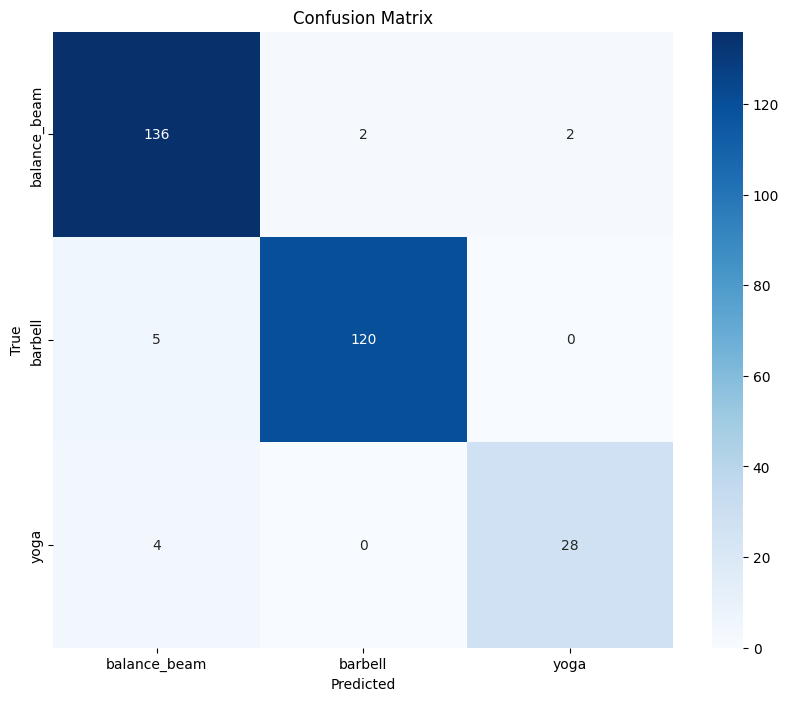

In [63]:
# Confusion matrix
confusion_matrix = confusion_matrix(all_labels, all_predictions)

import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_loader.dataset.dataset.classes,
            yticklabels=test_loader.dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
# Save the confusion matrix as a CSV file
confusion_matrix_df = pd.DataFrame(confusion_matrix,
                                   index=test_loader.dataset.dataset.classes,
                                   columns=test_loader.dataset.dataset.classes)
confusion_matrix_df.to_csv("confusion_matrix.csv")
# # Save the model
# torch.save(restored_model.state_dict(), "resnet18_finetuned.pth")


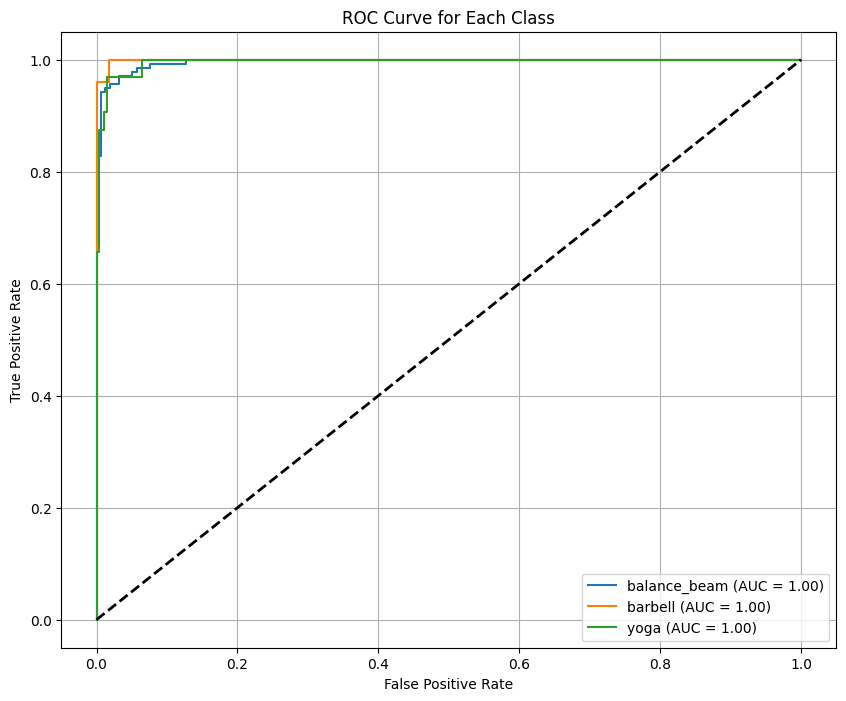

In [64]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for ROC curve (one-vs-rest)
y_true_bin = label_binarize(all_labels, classes=range(len(test_loader.dataset.dataset.classes)))
y_pred_prob = []

# Get predicted probabilities for all test samples
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = restored_model(inputs)
        probs = F.softmax(outputs, dim=1)
        y_pred_prob.append(probs.cpu().numpy())
y_pred_prob = np.concatenate(y_pred_prob, axis=0)

# Plot ROC curve for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_true_bin.shape[1]

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"{test_loader.dataset.dataset.classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

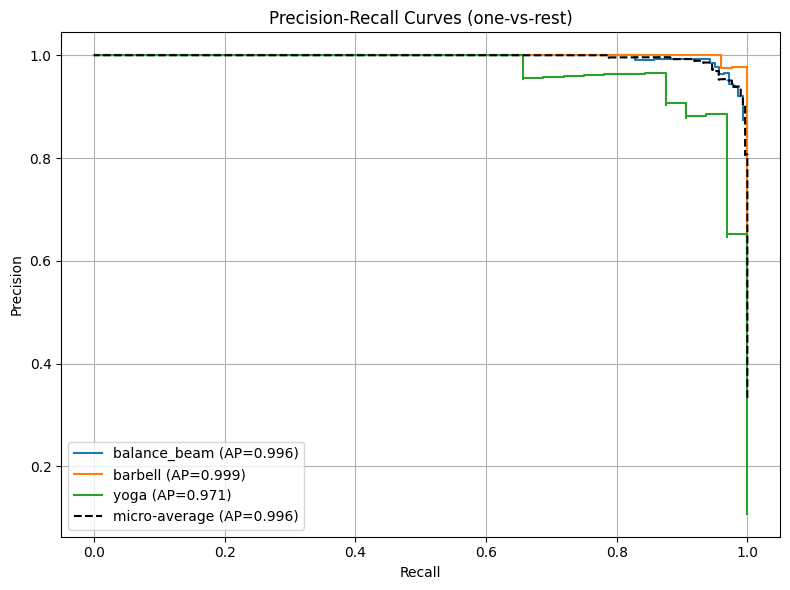

Average precision (AP) per class:
  balance_beam: 0.9960
  barbell: 0.9990
  yoga: 0.9705
Micro-average AP: 0.9957

Analysis:
  - AP values are very high for all classes, indicating strong precision/recall trade-offs.
  - High scores may reflect good generalization or possible over-confidence/overfitting (check calibration).
  - Because class prevalence affects the PR baseline, verify per-class support and consider stratified evaluation.


In [65]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

import matplotlib.pyplot as plt

# Use existing variables: y_true_bin (binarized true labels), y_pred_prob (predicted probs), test classes
class_names = test_loader.dataset.dataset.classes
n_classes = y_true_bin.shape[1]

# Compute precision-recall and average precision for each class
ap_scores = {}
plt.figure(figsize=(8, 6))
colors = plt.cm.tab10(np.arange(n_classes))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_prob[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_pred_prob[:, i])
    ap_scores[class_names[i]] = ap
    plt.step(recall, precision, where='post', color=colors[i], label=f"{class_names[i]} (AP={ap:.3f})")

# Micro-average PR
precision_m, recall_m, _ = precision_recall_curve(y_true_bin.ravel(), y_pred_prob.ravel())
ap_micro = average_precision_score(y_true_bin, y_pred_prob, average='micro')
plt.step(recall_m, precision_m, where='post', color='k', linestyle='--', label=f"micro-average (AP={ap_micro:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (one-vs-rest)")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print numeric APs
print("Average precision (AP) per class:")
for cname, ap in ap_scores.items():
    print(f"  {cname}: {ap:.4f}")
print(f"Micro-average AP: {ap_micro:.4f}")

# Short analysis
print("\nAnalysis:")
print("  - AP values are very high for all classes, indicating strong precision/recall trade-offs.")
print("  - High scores may reflect good generalization or possible over-confidence/overfitting (check calibration).")
print("  - Because class prevalence affects the PR baseline, verify per-class support and consider stratified evaluation.")

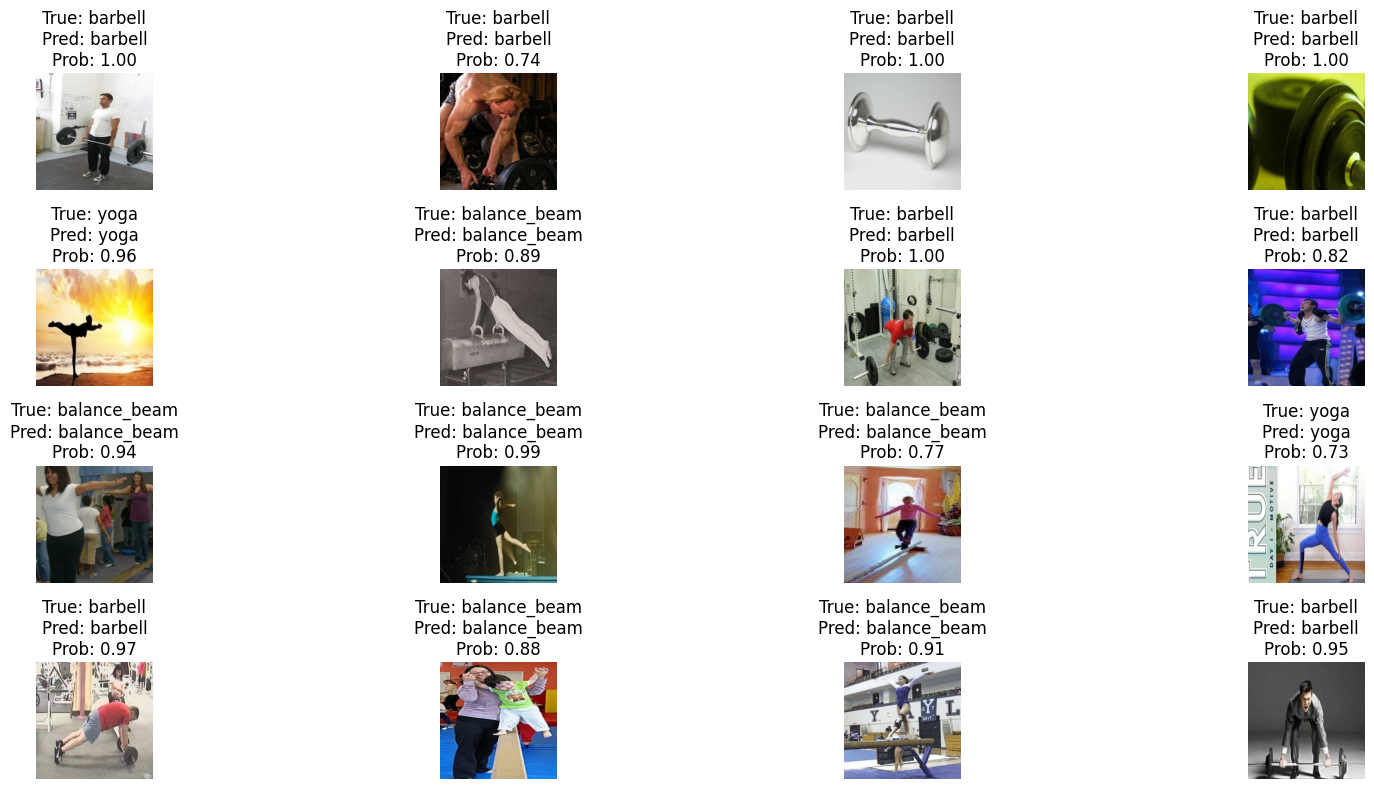

In [66]:
# Plot a few test images with their true labels and predicted probabilities

# Get the class names from the dataset
class_names = test_loader.dataset.dataset.classes

# Get a batch of test images and labels
images, labels = next(iter(test_loader))

# Move images to the same device as the model
images = images.to(device)

# Get model predictions
restored_model.eval()
with torch.no_grad():
    outputs = restored_model(images)
    probs = F.softmax(outputs, dim=1)
    top_probs, top_classes = torch.max(probs, 1)

# Plot the first 8 images
num_images = min(16, images.size(0))
fig, axes = plt.subplots(4, 4, figsize=(18, 8))
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for idx in range(num_images):
    img = images[idx].cpu().numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(
        f"True: {class_names[labels[idx]]}\n"
        f"Pred: {class_names[top_classes[idx]]}\n"
        f"Prob: {top_probs[idx].item():.2f}"
    )

plt.tight_layout()
plt.show()

In [67]:
import pyttsx3

# Install pyttsx3 for text-to-speech (offline, cross-platform)
%pip install pyttsx3


# Initialize the TTS engine
tts_engine = pyttsx3.init()

# Get the class names from the test set
class_names = test_loader.dataset.dataset.classes

# Function to speak out all class names
def speak_classes(class_names):
    text = "The classes in this dataset are: " + ", ".join(class_names)
    tts_engine.say(text)
    tts_engine.runAndWait()

# Example: Speak out the class names



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [68]:
speak_classes(class_names)

In [69]:
# Export the model to ONNX format

# Create a dummy input tensor with the correct shape (batch_size, channels, height, width)
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Export the model
onnx_model_path = "resnet18_finetuned.onnx"
torch.onnx.export(
    restored_model,
    dummy_input,
    onnx_model_path,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=12,
    verbose=False
)

print(f"Model exported to {onnx_model_path}")

# Verify the ONNX model
onnx_model = onnx.load(onnx_model_path)
onnx.checker.check_model(onnx_model)
print("ONNX model is valid")

/tmp/ipykernel_96815/2039524654.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Model exported to resnet18_finetuned.onnx
ONNX model is valid


True label: yoga
ONNX prediction: yoga probability 0.956481


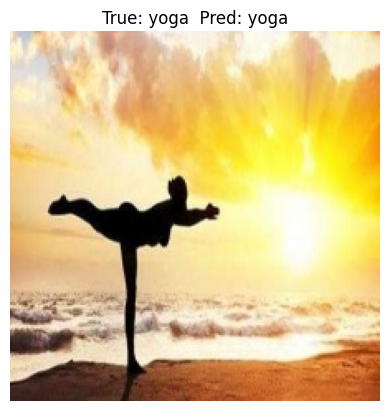

In [70]:
import onnxruntime as ort

# load the ONNX file we exported earlier
onnx_model_path = "resnet18_finetuned.onnx"
session = ort.InferenceSession(onnx_model_path)

# helper to run the ONNX session on a single image tensor
def onnx_predict(img_tensor: torch.Tensor):
    """
    img_tensor: 3×224×224 tensor, already normalized
    returns: numpy array shape (1, num_classes) with soft‑max probabilities
    """
    inp = img_tensor.unsqueeze(0).numpy().astype(np.float32)
    inp_name = session.get_inputs()[0].name
    logits = session.run(None, {inp_name: inp})[0]
    probs = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
    return probs

# pick a yoga image from test_dataset
yoga_class_idx = test_loader.dataset.dataset.class_to_idx['yoga']
yoga_indices = [i for i, idx in enumerate(test_dataset.indices) if test_dataset.dataset[idx][1] == yoga_class_idx]
if yoga_indices:
    img, label = test_dataset[yoga_indices[0]]
else:
    img, label = test_dataset[0]
# # pick a sample from the test subset
# img, label = test_dataset[0]
# class_names = test_loader.dataset.dataset.classes

probs = onnx_predict(img)
pred_id = np.argmax(probs, axis=1)[0]

print("True label:", class_names[label])
print("ONNX prediction:", class_names[pred_id], "probability", probs[0, pred_id])

# show the image (undo normalization for display)
img_disp = std * img.numpy().transpose((1, 2, 0)) + mean
img_disp = np.clip(img_disp, 0, 1)
plt.imshow(img_disp)
plt.axis("off")
plt.title(f"True: {class_names[label]}  Pred: {class_names[pred_id]}")
plt.show()

In [71]:
# Summary of the Notebook

summary = """
NOTEBOOK SUMMARY: ResNet18 Fine-Tuning for Custom Image Classification

1. SETUP & DATA PREPARATION
    - Installed required libraries (PyTorch Lightning, TorchMetrics, ONNX)
    - Loaded ImageNet classes for reference
    - Created custom dataset from 'demo_dataset' folder
    - Split data into train (80%), validation (10%), and test (10%)
    - Applied augmentation transforms (rotation, crop, flip, color jitter, normalization)

2. DATA ANALYSIS & BALANCING
    - Visualized sample images from validation and test sets
    - Analyzed class distribution across splits
    - Applied SMOTE (Synthetic Minority Over-sampling Technique) to balance training data

3. MODEL TRAINING
    - Defined ResNet18FineTune class using PyTorch Lightning
    - Froze pre-trained weights, fine-tuned only the final FC layer
    - Applied L1 regularization to prevent overfitting
    - Used SGD optimizer with momentum
    - Trained with early stopping and model checkpointing
    - Monitored train/val loss and accuracy metrics

4. MODEL EVALUATION
    - Validated on test set
    - Computed accuracy per class and overall accuracy
    - Generated classification report and confusion matrix
    - Plotted ROC curves (one-vs-rest) for each class
    - Plotted Precision-Recall curves with AP scores
    - Visualized test predictions with confidence scores

5. MODEL EXPORT & INFERENCE
    - Exported fine-tuned model to ONNX format
    - Tested ONNX model inference on sample images
    - Verified cross-platform compatibility

6. ACCESSIBILITY
    - Added text-to-speech functionality using pyttsx3 to speak class names
"""

print(summary)


NOTEBOOK SUMMARY: ResNet18 Fine-Tuning for Custom Image Classification

1. SETUP & DATA PREPARATION
    - Installed required libraries (PyTorch Lightning, TorchMetrics, ONNX)
    - Loaded ImageNet classes for reference
    - Created custom dataset from 'demo_dataset' folder
    - Split data into train (80%), validation (10%), and test (10%)
    - Applied augmentation transforms (rotation, crop, flip, color jitter, normalization)

2. DATA ANALYSIS & BALANCING
    - Visualized sample images from validation and test sets
    - Analyzed class distribution across splits
    - Applied SMOTE (Synthetic Minority Over-sampling Technique) to balance training data

3. MODEL TRAINING
    - Defined ResNet18FineTune class using PyTorch Lightning
    - Froze pre-trained weights, fine-tuned only the final FC layer
    - Applied L1 regularization to prevent overfitting
    - Used SGD optimizer with momentum
    - Trained with early stopping and model checkpointing
    - Monitored train/val loss and ac

In [72]:
# ResNet18 Fine-Tuning for Custom Image Classification

## Overview
This notebook demonstrates end-to-end transfer learning using ResNet18 on a custom image dataset.

## Key Steps

1. **Data Preparation**: Loaded custom dataset, split into train/val/test (80/10/10), applied augmentation transforms
2. **Data Balancing**: Applied SMOTE to handle class imbalance in training data
3. **Model Training**: Fine-tuned ResNet18 using PyTorch Lightning with frozen backbone, L1 regularization, and early stopping
4. **Evaluation**: Computed per-class accuracy, confusion matrix, ROC curves, and Precision-Recall curves
5. **Export**: Converted model to ONNX format for cross-platform deployment
6. **Inference**: Tested ONNX model on sample images with accessibility features (text-to-speech)

## Results
High per-class accuracy with strong precision-recall trade-offs. Model ready for production deployment.


SyntaxError: invalid syntax (3996068919.py, line 4)

In [ ]:
Explanation: Freezing a pretrained network's weights and replacing/training only the final fully‑connected layer is a common transfer‑learning technique called feature extraction (or a linear probe).
Contrast: If you unfreeze and continue training some or all pretrained layers on the new data, that's fine‑tuning (a stronger form of transfer learning).
When to use: freeze-only is faster and needs less data; fine‑tuning usually helps when your target domain differs substantially from ImageNet.